In [1]:
import sys, os
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
from joblib import Parallel, delayed

THERMOIFT_SRC = Path("../thermoift/src").resolve()
if str(THERMOIFT_SRC) not in sys.path:
    sys.path.insert(0, str(THERMOIFT_SRC))

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
from thermoift import PLOT_SETTINGS as ps
from matplotlib.ticker import FuncFormatter
from thermoift import MLPreprocessing

N_JOBS = os.cpu_count()
print(f"Using {N_JOBS} CPUs")

Using 24 CPUs


In [2]:
JOB_ID = "1693211"

def _load(i):
    p = f"../DATASET_A4/{JOB_ID}/{JOB_ID}_{i}/CSV/InterfacialProperties/feed_1_interfacial_results.csv"
    try:
        df = pd.read_csv(p)
        df = df[(df["vapor_density"] < 400) & (df["interfacial_thickness"] > 0)]
        df["source_id"] = i
        return df
    except FileNotFoundError:
        print(f"Missing: {p}")
        return None

with ThreadPoolExecutor(max_workers=N_JOBS) as pool:
    results = list(pool.map(_load, range(100)))

dfs = [r for r in results if r is not None]

if not dfs:
    raise FileNotFoundError(f"No interfacial result CSV files found for JOB_ID={JOB_ID!r}")

combined_df = pd.concat(dfs, ignore_index=True)
combined_df = combined_df.dropna(subset=["gamma"])
combined_df.to_csv("interfacial_results_dataset_A4.csv", index=False)

print(f"Loaded {len(dfs)} files in parallel. Total rows: {len(combined_df)}")

Loaded 100 files in parallel. Total rows: 19361


In [3]:
_math_fmt = FuncFormatter(lambda x, _: rf"${x:.2f}$")

# ── shared sizing constants (must match KS cell) ──────────────────────────
CELL_SIZE = 0.85   # inches per heatmap cell
ANNOT_PT  = 18     # annotation text inside cells
TICK_PT   = 22     # axis tick labels
LABEL_PT  = 26     # axis / colorbar label
CBAR_FRACTION = 0.03  # colorbar width relative to axes
CBAR_SHRINK   = 3    # colorbar height relative to axes

# ── columns ──────────────────────────────────────────────────────────────
COMPONENTS = [
    "carbon dioxide", "hydrogen", "argon", "nitrogen",
    "methane", "oxygen", "carbon monoxide", "hydrogen sulfide"
]

z_cols = [f"z_{c}" for c in COMPONENTS if f"z_{c}" in combined_df.columns]

features = ["temperature", "pressure"] + z_cols
targets = [
    "P_bubble", "P_dew",
    "liquid_density", "vapor_density",
    "Tc", "Pc",
    "gamma0_CO2", "rhoL0_CO2", "rhoV0_CO2",
    "gamma", "interfacial_thickness",
]

cols = [
    c for c in features + targets
    if c in combined_df.columns and combined_df[c].nunique() > 1
]

# ── Spearman correlation ─────────────────────────────────────────────────
corr = combined_df[cols].corr(method="spearman")

# ── label map (symbol only, no units) ────────────────────────────────────
comp_tex = {
    "carbon dioxide":  r"\mathrm{CO_2}",
    "hydrogen":        r"\mathrm{H_2}",
    "argon":           r"\mathrm{Ar}",
    "nitrogen":        r"\mathrm{N_2}",
    "methane":         r"\mathrm{CH_4}",
    "oxygen":          r"\mathrm{O_2}",
    "carbon monoxide": r"\mathrm{CO}",
    "hydrogen sulfide": r"\mathrm{H_2S}",
}

label_map = {
    "temperature":           r"$\mathit{T}$",
    "pressure":              r"$\mathit{P}$",
    "P_bubble":              r"$P_{\mathrm{bubble}}$",
    "P_dew":                 r"$P_{\mathrm{dew}}$",
    "liquid_density":        r"$\rho_{\mathrm{L}}$",
    "vapor_density":         r"$\rho_{\mathrm{V}}$",
    "Tc":                    r"$T_{\mathrm{c}}$",
    "Pc":                    r"$P_{\mathrm{c}}$",
    "gamma0_CO2":            r"$\gamma^{0}_{\mathrm{CO_2}}$",
    "rhoL0_CO2":             r"$\rho^{0}_{\mathrm{L,CO_2}}$",
    "rhoV0_CO2":             r"$\rho^{0}_{\mathrm{V,CO_2}}$",
    "gamma":                 r"$\gamma$",
    "interfacial_thickness": r"$L^{90}_{10}$",
}

for comp, tex in comp_tex.items():
    label_map[f"z_{comp}"] = rf"$z_{{{tex}}}$"

corr = corr.rename(index=label_map, columns=label_map)

# ── figure ───────────────────────────────────────────────────────────────
n = len(cols)
fig_size = max(4.0, n * CELL_SIZE)
fig, ax = ps.plot_init(w=fig_size, h=fig_size)

# ── heatmap ──────────────────────────────────────────────────────────────
mask       = np.triu(np.ones_like(corr, dtype=bool), k=1)
corr_annot = corr.map(lambda v: rf"${v:.2f}$" if not np.isnan(v) else "")

cm = sns.heatmap(
    corr,
    ax=ax,
    annot=corr_annot, fmt="",
    cmap=ps.map,
    center=0,
    vmin=-1,
    vmax=1,
    mask=mask,
    square=True,
    linewidths=0.5,
    annot_kws={"size": ANNOT_PT},
    cbar_kws={"shrink": CBAR_SHRINK, "fraction": CBAR_FRACTION, "extend": "both"},
)

# ── colorbar ─────────────────────────────────────────────────────────────
cbar = cm.collections[0].colorbar
ps.style_colorbar(cbar)

cbar.ax.tick_params(
    width=ps.tick_width,
    length=ps.tick_length,
    labelsize=TICK_PT,
)

cbar.set_label(
    r"$\mathrm{Spearman}$ $\rho_{\mathrm{s}}$ / $[-]$",
    fontsize=LABEL_PT,
    labelpad=15,
)

cbar.ax.yaxis.set_major_formatter(_math_fmt)
cbar.outline.set_linewidth(1.0)

# ── axes style ───────────────────────────────────────────────────────────
ps.apply_axis_style(ax)

ax.tick_params(
    axis="x", which="both", direction="out",
    length=ps.tick_length, width=ps.tick_width, labelsize=TICK_PT,
    bottom=True, top=False, labelbottom=True, labeltop=False,
)

ax.tick_params(
    axis="y", which="both", direction="out",
    length=ps.tick_length, width=ps.tick_width, labelsize=TICK_PT,
    left=True, right=False, labelleft=True, labelright=False,
)

ax.set_xticks(np.arange(len(corr.columns)) + 0.5)
ax.set_yticks(np.arange(len(corr.index)) + 0.5)

ax.set_xticklabels(corr.columns, fontsize=LABEL_PT, rotation=45,
                   ha="right", rotation_mode="anchor")
ax.set_yticklabels(corr.index, fontsize=LABEL_PT, rotation=0)

plt.tight_layout()
ps.save_plot(fig, "spearman_correlation_matrix")
plt.show()

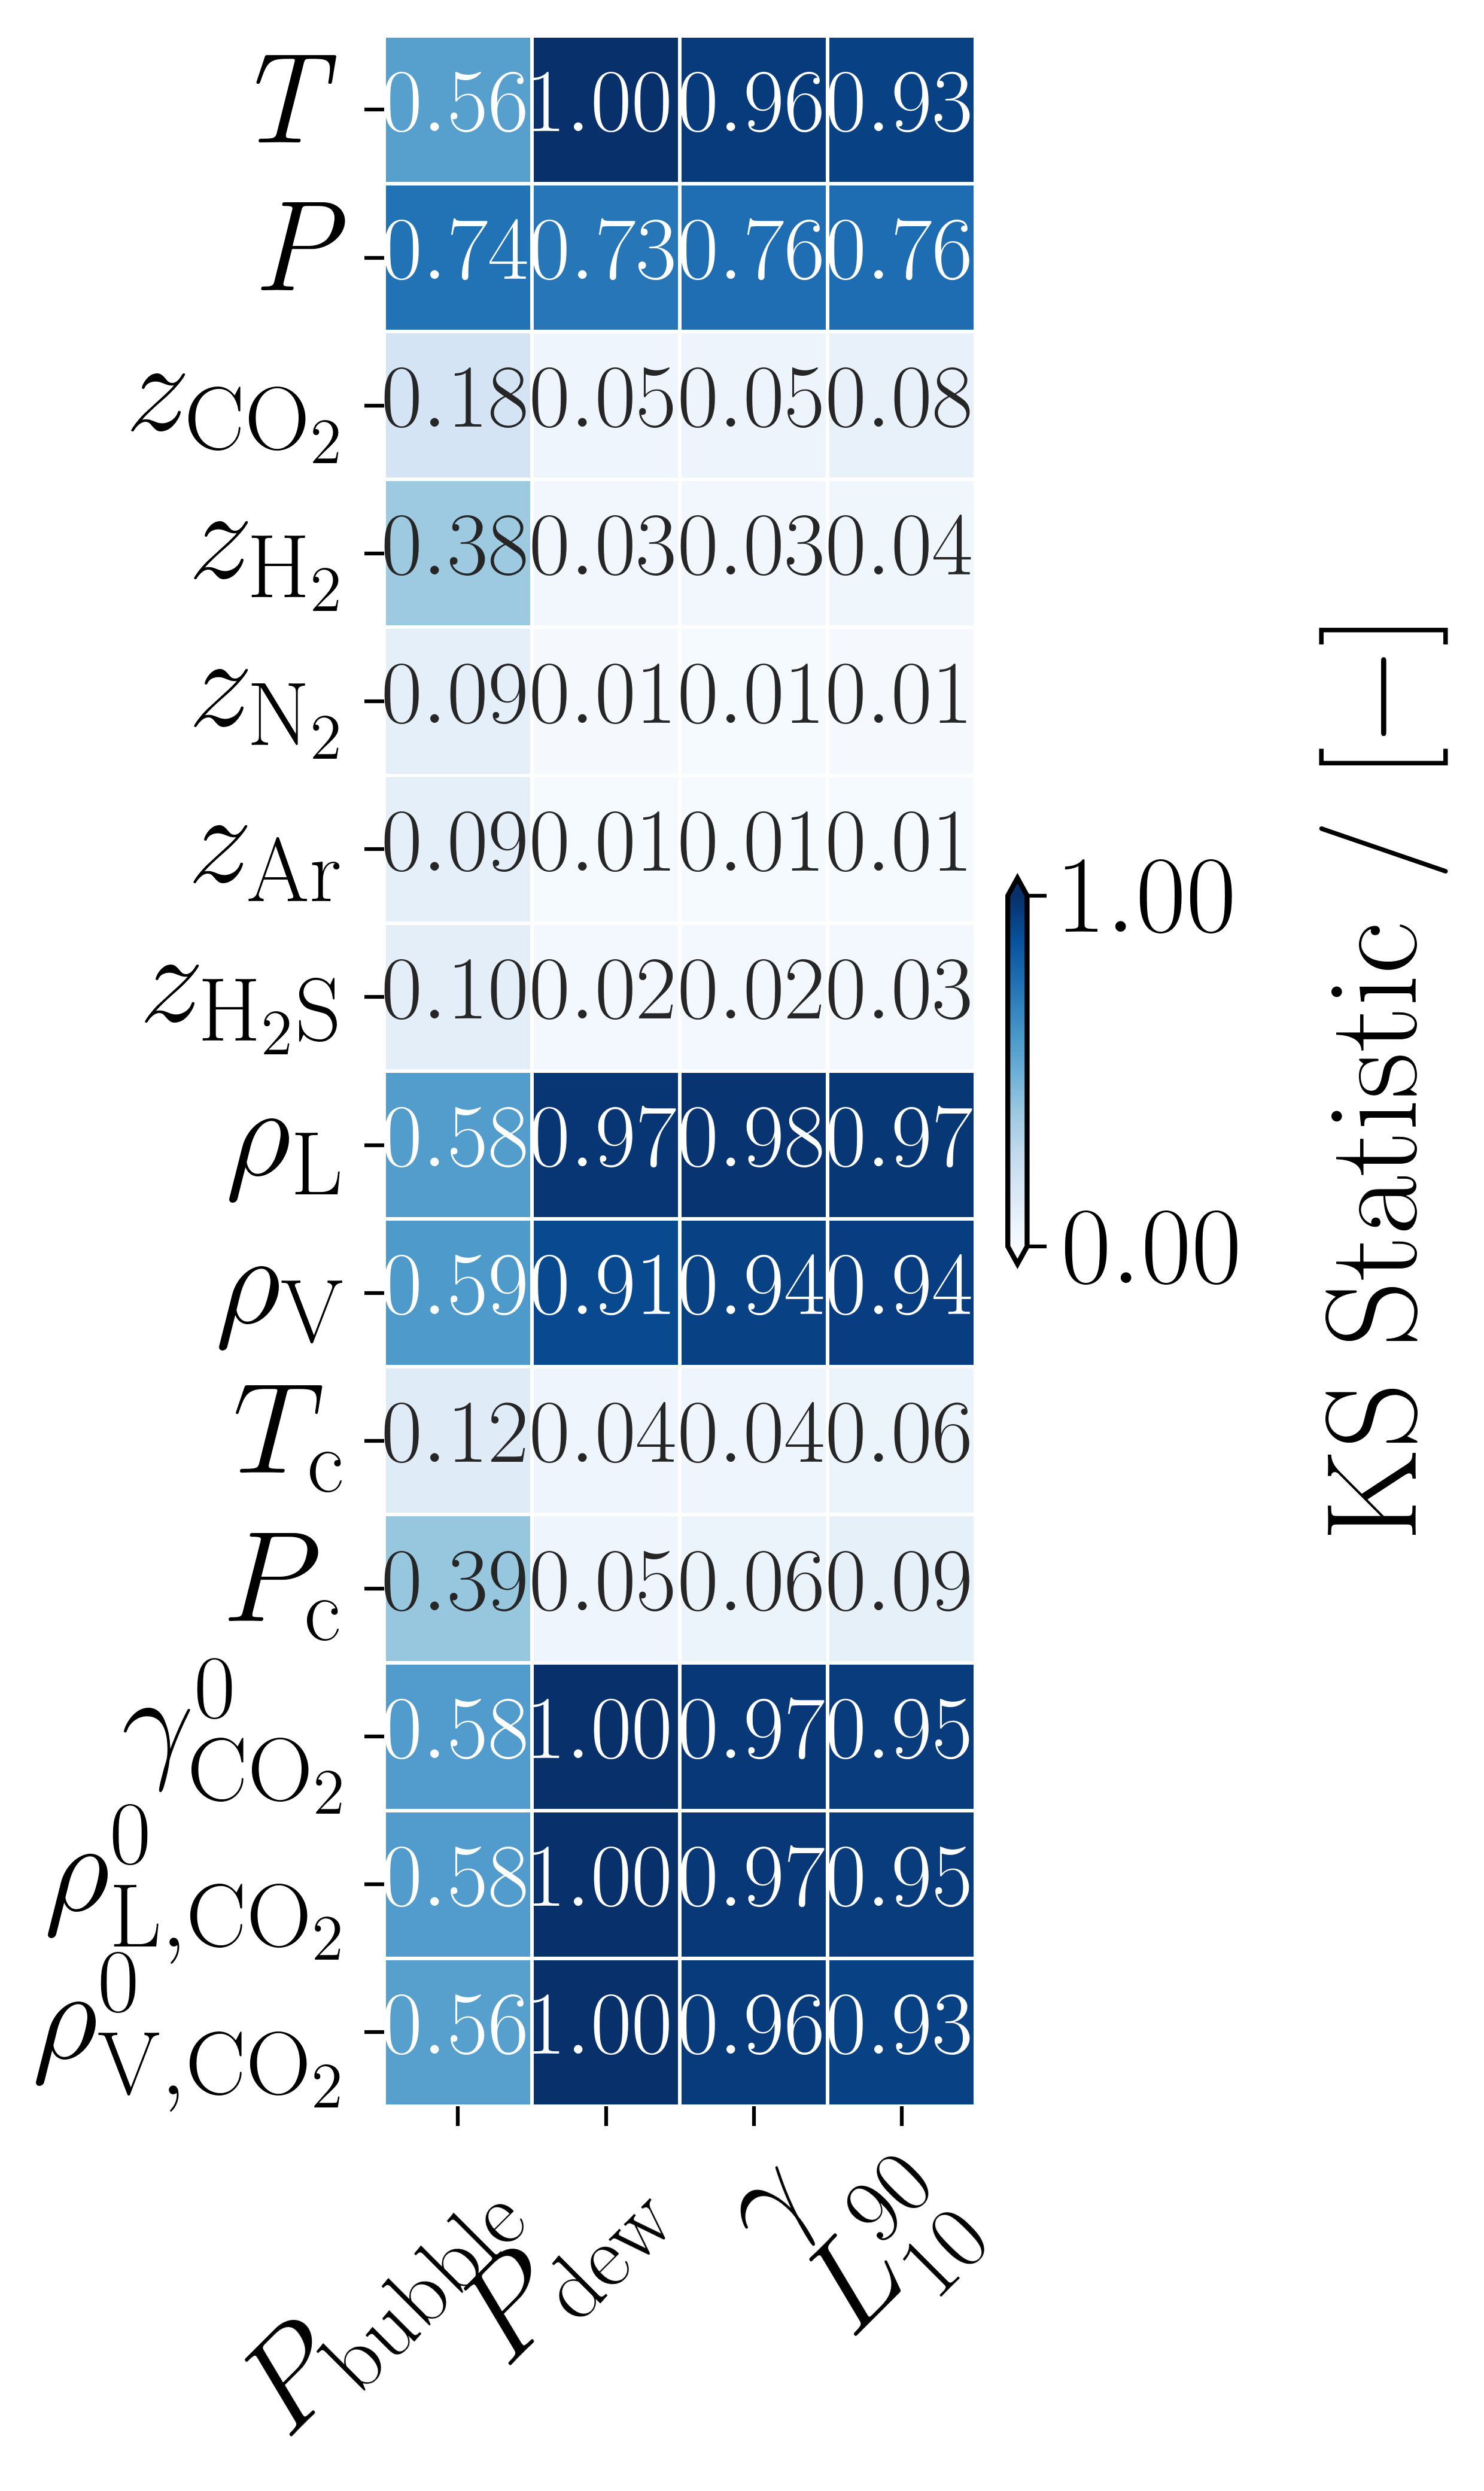

In [4]:
_math_fmt = FuncFormatter(lambda x, _: rf"${x:.2f}$")

# ── shared sizing constants (must match Spearman cell) ───────────────────
CELL_SIZE     = 0.85
ANNOT_PT      = 18
TICK_PT       = 22
LABEL_PT      = 26
CBAR_FRACTION = 0.03
CBAR_SHRINK   = 1.2

# ── features (y-axis): raw inputs + intermediate thermodynamic outputs ────
#   T, P, z_i  →  [PC-SAFT VLE]  →  these  →  [cDFT]  →  gamma, thickness
z_cols = [c for c in combined_df.columns
          if c.startswith('z_') and combined_df[c].nunique() > 1]

all_features = (
    ["temperature", "pressure"] +
    z_cols +
    ["liquid_density", "vapor_density",
     "Tc", "Pc",
     "gamma0_CO2", "rhoL0_CO2", "rhoV0_CO2"]
)
all_features = [f for f in all_features if f in combined_df.columns]

feat_label_map = {
    **label_map,
    "P_bubble":       r"$P_{\mathrm{bubble}}$",
    "P_dew":          r"$P_{\mathrm{dew}}$",
    "liquid_density": r"$\rho_{\mathrm{L}}$",
    "vapor_density":  r"$\rho_{\mathrm{V}}$",
    "Tc":             r"$T_{\mathrm{c}}$",
    "Pc":             r"$P_{\mathrm{c}}$",
    "gamma0_CO2":     r"$\gamma^{0}_{\mathrm{CO_2}}$",
    "rhoL0_CO2":      r"$\rho^{0}_{\mathrm{L,CO_2}}$",
    "rhoV0_CO2":      r"$\rho^{0}_{\mathrm{V,CO_2}}$",
}
feat_labels = [feat_label_map.get(f, f) for f in all_features]

# ── targets (x-axis): VLE outputs + final interfacial outputs ────────────
targets_ev    = ["P_bubble", "P_dew", "gamma", "interfacial_thickness"]
target_labels = [r"$P_{\mathrm{bubble}}$", r"$P_{\mathrm{dew}}$",
                 r"$\gamma$", r"$L^{90}_{10}$"]

valid = [(t, l) for t, l in zip(targets_ev, target_labels) if t in combined_df.columns]
targets_ev, target_labels = (list(x) for x in zip(*valid)) if valid else ([], [])

# ── KS statistic – all (feature, target) pairs in parallel ───────────────
def _ks_worker(feat, tgt, df):
    med = df[feat].median()
    lo  = df[df[feat] <  med][tgt].dropna().values
    hi  = df[df[feat] >= med][tgt].dropna().values
    if len(lo) > 1 and len(hi) > 1:
        return ks_2samp(lo, hi)[0]
    return np.nan

flat = Parallel(n_jobs=N_JOBS, prefer="threads")(
    delayed(_ks_worker)(feat, tgt, combined_df)
    for feat in all_features
    for tgt in targets_ev
)
ks_stat = np.array(flat).reshape(len(all_features), len(targets_ev))

# drop features with negligible influence (max KS < 0.02 across all targets)
keep          = np.nanmax(ks_stat, axis=1) >= 0.02
ks_stat_f     = ks_stat[keep]
feat_labels_f = [l for l, k in zip(feat_labels, keep) if k]

# ── figure ───────────────────────────────────────────────────────────────
ks_df  = pd.DataFrame(ks_stat_f, index=feat_labels_f, columns=target_labels).T
ks_ann = ks_df.map(lambda v: rf"${v:.2f}$" if not np.isnan(v) else "")

n_rows, n_cols = ks_df.shape          # (n_targets, n_features) after .T
fig_h = max(4.0, n_rows * CELL_SIZE)
fig_w = max(4.0, n_cols * CELL_SIZE)
fig, ax = ps.plot_init(w=fig_w, h=fig_h)

cm_ks = sns.heatmap(
    ks_df, ax=ax,
    annot=ks_ann, fmt='',
    cmap='Blues', vmin=0, vmax=1,
    square=True, linewidths=0.5,
    annot_kws={'size': ANNOT_PT},
    cbar_kws={'shrink': CBAR_SHRINK, 'fraction': CBAR_FRACTION, 'extend': 'both'},
)

# ── colorbar ─────────────────────────────────────────────────────────────
cbar_ks = cm_ks.collections[0].colorbar
ps.style_colorbar(cbar_ks)
cbar_ks.ax.tick_params(width=ps.tick_width, length=ps.tick_length, labelsize=TICK_PT)
cbar_ks.set_label(r"$\mathrm{KS \; Statistic}$ / $[-]$", fontsize=LABEL_PT, labelpad=15)
cbar_ks.outline.set_linewidth(1.0)
cbar_ks.ax.yaxis.set_major_formatter(_math_fmt)

# ── axes style ───────────────────────────────────────────────────────────
ps.apply_axis_style(ax)

ax.tick_params(axis='x', which='both', direction='out',
               length=ps.tick_length, width=ps.tick_width, labelsize=TICK_PT,
               bottom=True, top=False, labelbottom=True, labeltop=False)
ax.tick_params(axis='y', which='both', direction='out',
               length=ps.tick_length, width=ps.tick_width, labelsize=TICK_PT,
               left=True, right=False, labelleft=True, labelright=False)

ax.set_xticks(np.arange(n_cols) + 0.5)
ax.set_yticks(np.arange(n_rows) + 0.5)

ax.set_xticklabels(ks_df.columns.tolist(), fontsize=LABEL_PT, rotation=45,
                   ha='right', rotation_mode='anchor')
ax.set_yticklabels(ks_df.index.tolist(), fontsize=LABEL_PT, rotation=0)

plt.tight_layout()
ps.save_plot(fig, "ks_statistic")
plt.show()

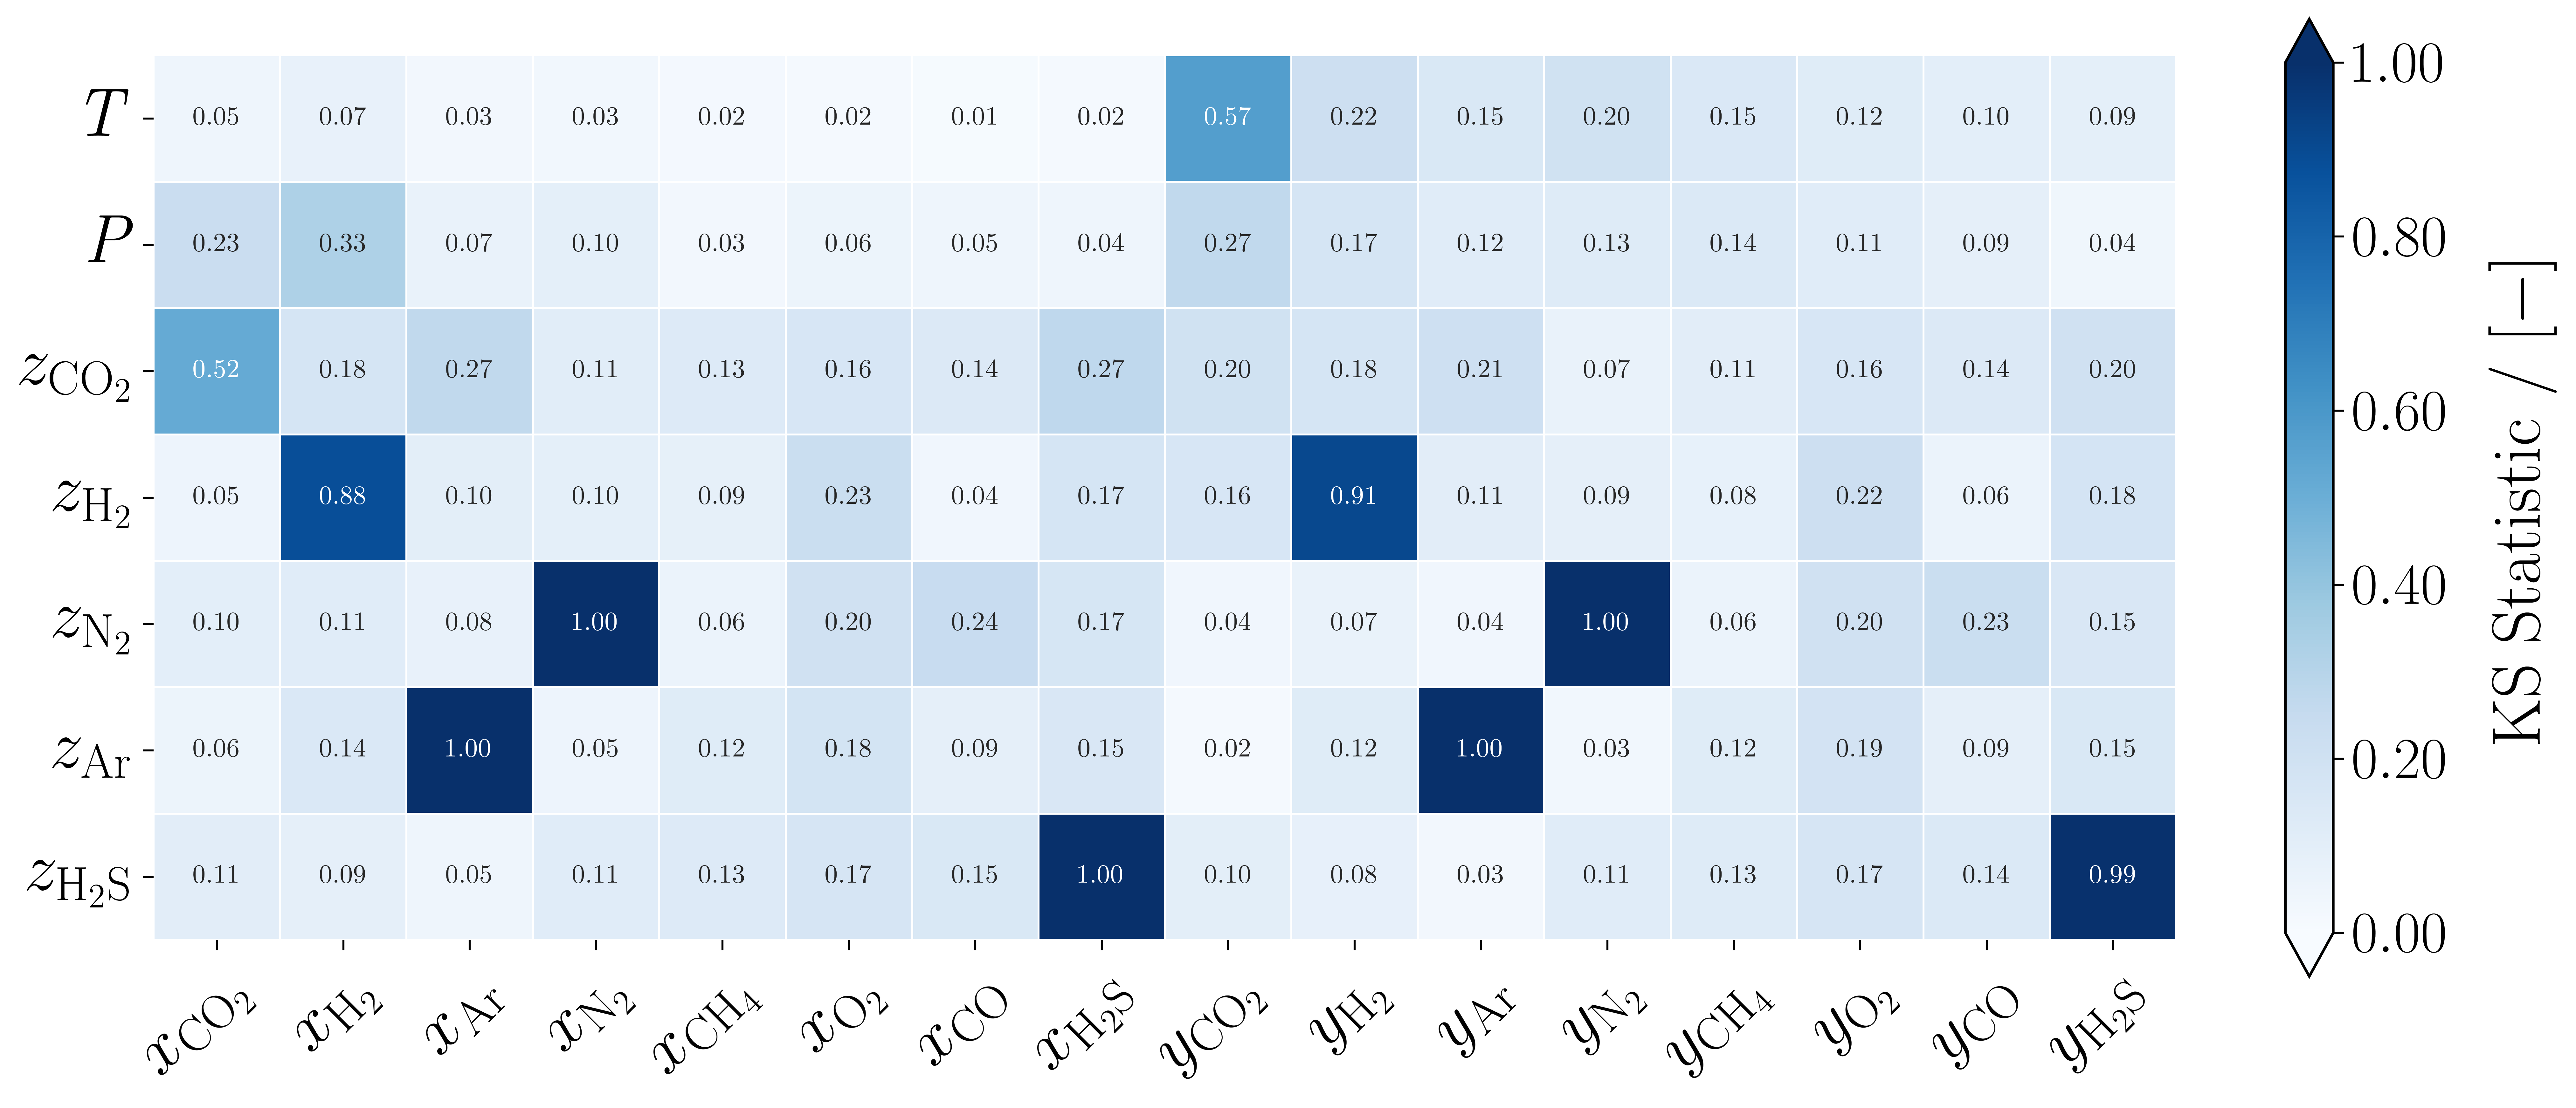

In [5]:
_math_fmt = FuncFormatter(lambda x, _: rf"${x:.2f}$")

# ── shared sizing constants (match Spearman / KS cells) ──────────────────
CELL_SIZE     = 0.85
ANNOT_PT      = 10
TICK_PT       = 22
LABEL_PT      = 26
CBAR_FRACTION = 0.022
CBAR_SHRINK   = 1.0

# ── phase-composition targets: liquid x_i and vapor y_i ──────────────────
COMPONENTS = [
    "carbon dioxide", "hydrogen", "argon", "nitrogen",
    "methane", "oxygen", "carbon monoxide", "hydrogen sulfide",
]

x_cols = [f"x_{c}" for c in COMPONENTS if f"x_{c}" in combined_df.columns]
y_cols = [f"y_{c}" for c in COMPONENTS if f"y_{c}" in combined_df.columns]

comp_tex = {
    "carbon dioxide":   r"\mathrm{CO_2}",
    "hydrogen":         r"\mathrm{H_2}",
    "argon":            r"\mathrm{Ar}",
    "nitrogen":         r"\mathrm{N_2}",
    "methane":          r"\mathrm{CH_4}",
    "oxygen":           r"\mathrm{O_2}",
    "carbon monoxide":  r"\mathrm{CO}",
    "hydrogen sulfide": r"\mathrm{H_2S}",
}

phase_label_map = {}
for comp, tex in comp_tex.items():
    phase_label_map[f"x_{comp}"] = rf"$x_{{{tex}}}$"
    phase_label_map[f"y_{comp}"] = rf"$y_{{{tex}}}$"

phase_targets = x_cols + y_cols
phase_labels  = [phase_label_map[c] for c in phase_targets]

# ── features: same T, P, z_i as the main KS plot ─────────────────────────
z_features  = ["temperature", "pressure"] + [
    c for c in combined_df.columns
    if c.startswith("z_") and combined_df[c].nunique() > 1
]
feat_labels = [label_map.get(f, f) for f in z_features]

# ── KS statistic – all (feature, target) pairs in parallel ───────────────
def _ks_worker(feat, tgt, df):
    med = df[feat].median()
    lo  = df[df[feat] <  med][tgt].dropna().values
    hi  = df[df[feat] >= med][tgt].dropna().values
    if len(lo) > 1 and len(hi) > 1:
        return ks_2samp(lo, hi)[0]
    return np.nan
flat = Parallel(n_jobs=N_JOBS, prefer="threads")(
    delayed(_ks_worker)(feat, tgt, combined_df)
    for feat in z_features
    for tgt in phase_targets
)
ks_phase = np.array(flat).reshape(len(z_features), len(phase_targets))

# drop features with no influence (max KS < 0.02)
keep_p         = np.nanmax(ks_phase, axis=1) >= 0.02
ks_phase_f     = ks_phase[keep_p]
feat_labels_pf = [l for l, k in zip(feat_labels, keep_p) if k]

# ── plot ─────────────────────────────────────────────────────────────────
ks_ph_df  = pd.DataFrame(ks_phase_f, index=feat_labels_pf, columns=phase_labels)
ks_ph_ann = ks_ph_df.map(lambda v: rf"${v:.2f}$" if not np.isnan(v) else "")

n_r, n_c = len(feat_labels_pf), len(phase_targets)
fig_h = max(4.0, n_r * CELL_SIZE)
fig_w = max(4.0, n_c * CELL_SIZE)
fig, ax = ps.plot_init(w=fig_w, h=fig_h)

cm_ph = sns.heatmap(
    ks_ph_df, ax=ax,
    annot=ks_ph_ann, fmt="",
    cmap="Blues", vmin=0, vmax=1,
    square=True, linewidths=0.5,
    annot_kws={"size": ANNOT_PT},
    cbar_kws={"shrink": CBAR_SHRINK, "fraction": CBAR_FRACTION, "extend": "both"},
)

cbar_ph = cm_ph.collections[0].colorbar
ps.style_colorbar(cbar_ph)
cbar_ph.ax.tick_params(width=ps.tick_width, length=ps.tick_length, labelsize=TICK_PT)
cbar_ph.set_label(r"$\mathrm{KS \; Statistic}$ / $[-]$", fontsize=LABEL_PT, labelpad=15)
cbar_ph.outline.set_linewidth(1.0)
cbar_ph.ax.yaxis.set_major_formatter(_math_fmt)

ps.apply_axis_style(ax)
ax.tick_params(axis="x", which="both", direction="out",
               length=ps.tick_length, width=ps.tick_width, labelsize=TICK_PT,
               bottom=True, top=False, labelbottom=True, labeltop=False)
ax.tick_params(axis="y", which="both", direction="out",
               length=ps.tick_length, width=ps.tick_width, labelsize=TICK_PT,
               left=True, right=False, labelleft=True, labelright=False)

ax.set_xticks(np.arange(len(phase_labels)) + 0.5)
ax.set_yticks(np.arange(len(feat_labels_pf)) + 0.5)

ax.set_xticklabels(phase_labels, fontsize=LABEL_PT, rotation=45,
                   ha="right", rotation_mode="anchor")
ax.set_yticklabels(feat_labels_pf, fontsize=LABEL_PT, rotation=0)

plt.tight_layout()
ps.save_plot(fig, "ks_statistic_phase_compositions")
plt.show()

In [6]:
target      = "gamma"
prep        = MLPreprocessing(df=combined_df, features=features, target=target)

# prep.plot_target_vs_temperature(save_path="gamma_vs_T")
# prep.plot_target_vs_pressure(save_path="gamma_vs_P")
# prep.plot_target_distribution(save_path="gamma_distribution")
# prep.plot_target_vs_liquid_density(save_path="gamma_vs_rhoL")
# prep.plot_target_vs_vapor_density(save_path="gamma_vs_rhoV")
# prep.plot_target_vs_interfacial_thickness(save_path="gamma_vs_thickness")
# prep.plot_target_phase_envelope(save_path="gamma_phase_envelope")